In [40]:
dataset_drive_url = (
    "https://drive.google.com/file/d/1qxpRjTCLh5rTJv1jHq3aXIeMxeRW5Eft/view?usp=sharing"
)

In [41]:
import re


def drive_to_direct_url(link: str) -> str:
    """
    Convert Google Drive share link to direct download URL.
    Works for multiple link formats.
    """
    patterns = [
        r'/file/d/([a-zA-Z0-9_-]+)',
        r'id=([a-zA-Z0-9_-]+)',
        r'/open\?id=([a-zA-Z0-9_-]+)'
    ]
    
    file_id = None
    
    for pattern in patterns:
        match = re.search(pattern, link)
        if match:
            file_id = match.group(1)
            break
    
    if not file_id:
        raise ValueError("Invalid Google Drive link")
    
    return f"https://drive.google.com/uc?id={file_id}"

In [42]:
import pandas as pd

df = pd.read_csv(drive_to_direct_url(dataset_drive_url))


In [43]:
df.head()

,age,gender,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diabetic
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5288 entries, 0 to 5287
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5288 non-null   int64  
 1   gender                  5288 non-null   object 
 2   pulse_rate              5288 non-null   int64  
 3   systolic_bp             5288 non-null   int64  
 4   diastolic_bp            5288 non-null   int64  
 5   glucose                 5288 non-null   float64
 6   height                  5288 non-null   float64
 7   weight                  5288 non-null   float64
 8   bmi                     5288 non-null   float64
 9   family_diabetes         5288 non-null   int64  
 10  hypertensive            5288 non-null   int64  
 11  family_hypertension     5288 non-null   int64  
 12  cardiovascular_disease  5288 non-null   int64  
 13  stroke                  5288 non-null   int64  
 14  diabetic                5288 non-null   

In [45]:
df.shape

(5288, 15)

In [46]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,5288.0,45.745651,13.422024,21.00,35.000,45.00,55.0000,80.00
pulse_rate,5288.0,76.626135,12.229319,5.00,69.000,76.00,84.0000,133.00
systolic_bp,5288.0,133.996596,22.231752,62.00,119.000,130.00,147.0000,231.00
diastolic_bp,5288.0,82.229576,12.479007,45.00,73.000,81.00,90.0000,119.00
glucose,5288.0,7.563922,2.944381,0.00,6.000,6.93,8.1300,33.46
height,5288.0,1.548886,0.080328,0.36,1.520,1.55,1.6000,1.96
weight,5288.0,53.644100,10.076059,3.00,46.775,53.00,59.9000,100.70
bmi,5288.0,22.466581,8.819898,1.22,19.620,21.87,24.4725,574.13
family_diabetes,5288.0,0.031959,0.175908,0.00,0.000,0.00,0.0000,1.00
hypertensive,5288.0,0.111006,0.314169,0.00,0.000,0.00,0.0000,1.00


In [47]:
df.columns.tolist()

['age',
 'gender',
 'pulse_rate',
 'systolic_bp',
 'diastolic_bp',
 'glucose',
 'height',
 'weight',
 'bmi',
 'family_diabetes',
 'hypertensive',
 'family_hypertension',
 'cardiovascular_disease',
 'stroke',
 'diabetic']

In [48]:
df.isnull().sum()

age                       0
gender                    0
pulse_rate                0
systolic_bp               0
diastolic_bp              0
glucose                   0
height                    0
weight                    0
bmi                       0
family_diabetes           0
hypertensive              0
family_hypertension       0
cardiovascular_disease    0
stroke                    0
diabetic                  0
dtype: int64

In [49]:
df.nunique()

age                         60
gender                       2
pulse_rate                  91
systolic_bp                136
diastolic_bp                73
glucose                    937
height                      54
weight                     509
bmi                       1370
family_diabetes              2
hypertensive                 2
family_hypertension          2
cardiovascular_disease       2
stroke                       2
diabetic                     2
dtype: int64

In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

numerical_cols

['age',
 'pulse_rate',
 'systolic_bp',
 'diastolic_bp',
 'glucose',
 'height',
 'weight',
 'bmi',
 'family_diabetes',
 'hypertensive',
 'family_hypertension',
 'cardiovascular_disease',
 'stroke']

In [52]:
df[numerical_cols].head()

,age,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke
0,42,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0
1,35,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0
2,62,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0
3,73,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0
4,68,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0


In [53]:
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

categorical_cols

['gender', 'diabetic']

In [54]:
continuous_cols = [
    "age",
    "pulse_rate",
    "systolic_bp",
    "diastolic_bp",
    "glucose",
    "height",
    "weight",
    "bmi"
]

In [55]:
binary_cols = [
    "family_diabetes",
    "hypertensive",
    "family_hypertension",
    "cardiovascular_disease",
    "stroke"
]

In [56]:
for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")
    print(f"Range: {lower:.2f} - {upper:.2f}")
    print()

age: 0 outliers
Range: 5.00 - 85.00

pulse_rate: 96 outliers
Range: 46.50 - 106.50

systolic_bp: 113 outliers
Range: 77.00 - 189.00

diastolic_bp: 54 outliers
Range: 47.50 - 115.50

glucose: 400 outliers
Range: 2.80 - 11.33

height: 193 outliers
Range: 1.40 - 1.72

weight: 79 outliers
Range: 27.09 - 79.59

bmi: 133 outliers
Range: 12.34 - 31.75



In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\Habib\AppData\Local\Temp\ipykernel_12812\2363214999.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


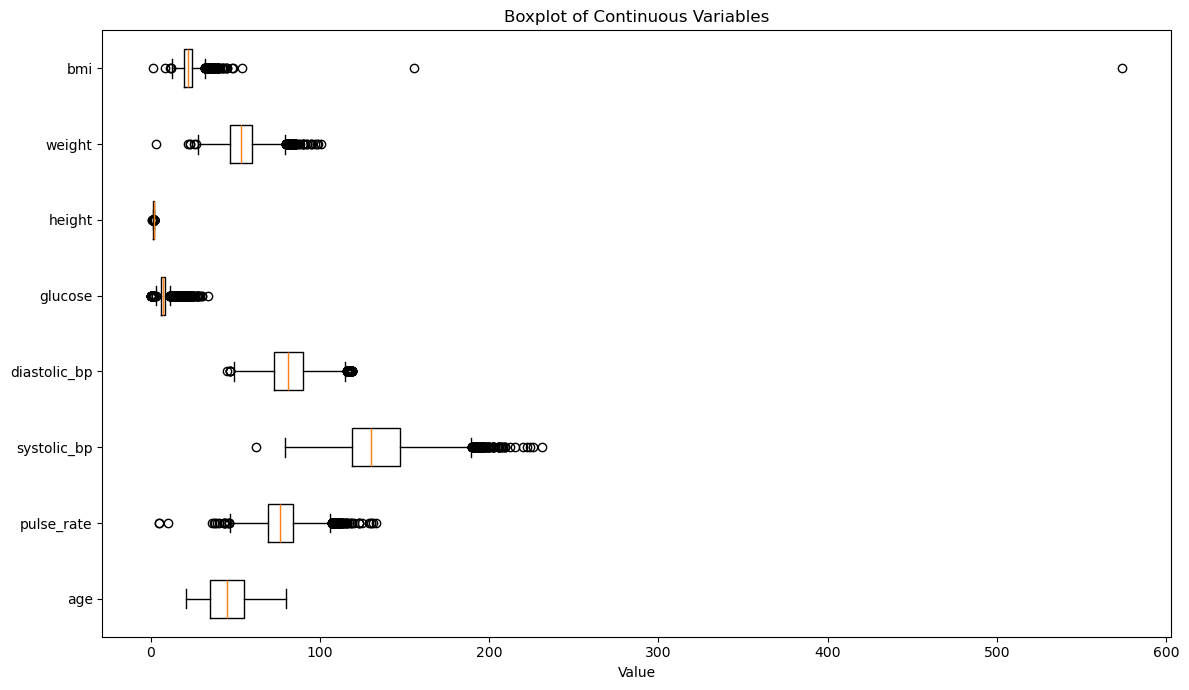

In [58]:
plt.figure(figsize=(12, 7))

plt.boxplot(
    [df[col].dropna() for col in continuous_cols],
    labels=continuous_cols,
    vert=False
)

plt.title("Boxplot of Continuous Variables")
plt.xlabel("Value")
plt.tight_layout()
plt.show()

In [59]:
df["age"].describe()

count    5288.000000
mean       45.745651
std        13.422024
min        21.000000
25%        35.000000
50%        45.000000
75%        55.000000
max        80.000000
Name: age, dtype: float64

In [60]:
df["pulse_rate"].describe()

count    5288.000000
mean       76.626135
std        12.229319
min         5.000000
25%        69.000000
50%        76.000000
75%        84.000000
max       133.000000
Name: pulse_rate, dtype: float64

In [61]:
df[df["pulse_rate"] < 30][
    ["age", "gender", "pulse_rate", "systolic_bp", "diastolic_bp"]
]

,age,gender,pulse_rate,systolic_bp,diastolic_bp
4812,70,Female,5,120,80
4894,40,Female,10,150,101
4900,60,Female,5,120,60


In [62]:
df = df[df["pulse_rate"] >= 30].copy()

In [63]:
df["systolic_bp"].describe()

count    5285.000000
mean      133.998865
std        22.235305
min        62.000000
25%       119.000000
50%       130.000000
75%       147.000000
max       231.000000
Name: systolic_bp, dtype: float64

In [64]:
df[df["systolic_bp"] < 80][
    ["age", "gender", "pulse_rate", "systolic_bp", "diastolic_bp"]
].sort_values("systolic_bp")

,age,gender,pulse_rate,systolic_bp,diastolic_bp
2045,60,Female,78,62,51
3425,35,Male,78,79,64


In [65]:
df[df["systolic_bp"] > 200][
    ["age", "gender", "pulse_rate", "systolic_bp", "diastolic_bp"]
].sort_values("systolic_bp")

,age,gender,pulse_rate,systolic_bp,diastolic_bp
5019,70,Male,50,201,108
401,46,Female,74,202,106
3895,55,Female,77,202,116
2011,80,Male,75,202,96
5111,55,Male,67,202,114
5071,40,Female,76,202,108
3896,70,Male,75,203,96
4980,65,Female,80,203,114
722,65,Male,91,205,110
1063,65,Male,86,205,119


In [66]:
df["diastolic_bp"].describe()

count    5285.000000
mean       82.230653
std        12.476092
min        45.000000
25%        73.000000
50%        81.000000
75%        90.000000
max       119.000000
Name: diastolic_bp, dtype: float64

In [67]:
df[df["diastolic_bp"] < 50][
    ["age", "gender", "pulse_rate", "systolic_bp", "diastolic_bp"]
].sort_values("diastolic_bp")

,age,gender,pulse_rate,systolic_bp,diastolic_bp
3953,47,Male,59,86,45
2387,35,Female,77,87,47
3157,65,Female,73,100,47
4008,43,Female,85,97,47
4014,35,Male,70,148,47
4009,55,Male,78,120,49


In [68]:
df[df["diastolic_bp"] > 115][
    ["age", "gender", "pulse_rate", "systolic_bp", "diastolic_bp"]
].sort_values("diastolic_bp")

,age,gender,pulse_rate,systolic_bp,diastolic_bp
627,45,Female,48,209,116
3181,39,Female,69,153,116
2395,50,Female,75,128,116
1889,29,Female,85,180,116
2608,55,Female,73,196,116
4516,65,Male,56,192,116
3877,51,Male,104,177,116
3895,55,Female,77,202,116
4558,35,Female,82,151,116
1572,55,Female,82,191,117


In [69]:
df["glucose"].describe()

count    5285.000000
mean        7.559323
std         2.934088
min         0.000000
25%         6.000000
50%         6.930000
75%         8.130000
max        33.460000
Name: glucose, dtype: float64

In [72]:
df[df["glucose"] < 1][
    ["age", "gender", "glucose", "diabetic"]
].sort_values("glucose")

,age,gender,glucose,diabetic
1138,28,Female,0.00,No
4144,30,Female,0.04,No
4718,50,Female,0.08,No
3510,60,Female,0.19,No
5005,49,Female,0.20,No
4209,35,Female,0.26,No
3655,78,Male,0.26,No
3331,60,Female,0.34,No
726,25,Female,0.43,No
1887,30,Female,0.45,No


In [73]:
df = df[df["glucose"] >= 1].copy()

In [74]:
df["glucose"].min()

1.0

In [75]:
df["bmi"].describe()

count    5267.000000
mean       22.470264
std         8.835414
min         1.220000
25%        19.630000
50%        21.870000
75%        24.490000
max       574.130000
Name: bmi, dtype: float64

In [76]:
df[df["bmi"] < 12][
    ["age", "gender", "height", "weight", "bmi"]
].sort_values("bmi")

,age,gender,height,weight,bmi
1279,46,Female,1.57,3.0,1.22
1731,70,Male,1.63,21.9,8.29
2392,70,Female,1.42,23.2,11.47


In [77]:
df[df["bmi"] > 50][
    ["age", "gender", "height", "weight", "bmi"]
].sort_values("bmi")

,age,gender,height,weight,bmi
3378,28,Female,1.35,98.0,54.08
885,75,Female,0.64,62.8,155.74
152,24,Male,0.36,72.6,574.13


In [78]:
df = df[(df["bmi"] >= 12) & (df["bmi"] <= 50)].copy()

In [79]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,5261.0,45.733131,13.404395,21.00,35.00,45.00,55.00,80.00
pulse_rate,5261.0,76.658240,12.117090,36.00,69.00,76.00,84.00,133.00
systolic_bp,5261.0,133.965786,22.227718,62.00,119.00,130.00,147.00,231.00
diastolic_bp,5261.0,82.224482,12.486174,45.00,73.00,81.00,90.00,119.00
glucose,5261.0,7.581732,2.908396,1.00,6.00,6.93,8.13,33.46
height,5261.0,1.549445,0.077564,0.99,1.52,1.55,1.60,1.96
weight,5261.0,53.667174,10.022345,23.00,46.80,53.00,59.90,100.70
bmi,5261.0,22.342891,4.070210,12.10,19.63,21.87,24.49,48.44
family_diabetes,5261.0,0.031933,0.175839,0.00,0.00,0.00,0.00,1.00
hypertensive,5261.0,0.111006,0.314169,0.00,0.00,0.00,0.00,1.00
